##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [24]:
!pip install tensorflow tensorflow_hub pillow requests pandas matplotlib

In [25]:
from __future__ import annotations

import io
from pathlib import Path
from typing import Iterable

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import tensorflow as tf
import tensorflow_hub as hub
from PIL import Image

In [26]:
# Use local image files instead of URLs
IMAGE_SOURCES: dict[str, list[str]] = {
    "cars_people": [r"C:\Users\WinDows\OneDrive\Documents\سطح المكتب\cars people.jpg"],
    "gang": [r"C:\Users\WinDows\OneDrive\Documents\سطح المكتب\gang.jpg"],
    "person": [r"C:\Users\WinDows\OneDrive\Documents\سطح المكتب\person.jpg"],
    "street": [r"C:\Users\WinDows\OneDrive\Documents\سطح المكتب\street.jpg"],
    "tamata_cat": [r"C:\Users\WinDows\OneDrive\Documents\سطح المكتب\tamata cat.jpg"],
}

TFHUB_MODEL_URL = "https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1"
OUTPUT_DIR = Path("outputs")
IMAGES_DIR = OUTPUT_DIR / "images"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

COCO_LABELS: dict[int, str] = {
    1: "person", 2: "bicycle", 3: "car", 4: "motorcycle", 5: "airplane",
    6: "bus", 7: "train", 8: "truck", 9: "boat", 10: "traffic light",
    11: "fire hydrant", 13: "stop sign", 14: "parking meter", 15: "bench",
    16: "bird", 17: "cat", 18: "dog", 19: "horse", 20: "sheep",
    21: "cow", 22: "elephant", 23: "bear", 24: "zebra", 25: "giraffe",
    27: "backpack", 28: "umbrella", 31: "handbag", 32: "tie", 33: "suitcase",
    34: "frisbee", 35: "skis", 36: "snowboard", 37: "sports ball", 38: "kite",
    39: "baseball bat", 40: "baseball glove", 41: "skateboard", 42: "surfboard",
    43: "tennis racket", 44: "bottle", 46: "wine glass", 47: "cup", 48: "fork",
    49: "knife", 50: "spoon", 51: "bowl", 52: "banana", 53: "apple",
    54: "sandwich", 55: "orange", 56: "broccoli", 57: "carrot", 58: "hot dog",
    59: "pizza", 60: "donut", 61: "cake", 62: "chair", 63: "couch",
    64: "potted plant", 65: "bed", 67: "dining table", 70: "toilet",
    72: "tv", 73: "laptop", 74: "mouse", 75: "remote", 76: "keyboard",
    77: "cell phone", 78: "microwave", 79: "oven", 80: "toaster",
    81: "sink", 82: "refrigerator", 84: "book", 85: "clock", 86: "vase",
    87: "scissors", 88: "teddy bear", 89: "hair drier", 90: "toothbrush",
}

In [27]:
def ensure_dirs() -> None:
    for directory in (OUTPUT_DIR, IMAGES_DIR, FIGURES_DIR, TABLES_DIR):
        directory.mkdir(parents=True, exist_ok=True)


def get_class_name(class_id: int) -> str:
    return COCO_LABELS.get(int(class_id), f"class_{int(class_id)}")


def load_detector() -> hub.KerasLayer:
    return hub.load(TFHUB_MODEL_URL)


def load_image_from_path(path_or_paths: str | Iterable[str]) -> np.ndarray:
    # Accept one path or a list of fallback paths
    candidates = [path_or_paths] if isinstance(path_or_paths, str) else list(path_or_paths)

    last_error: Exception | None = None
    for path in candidates:
        try:
            image = Image.open(path).convert("RGB")
            return np.array(image)
        except Exception as exc:
            last_error = exc
            print(f"  Failed to load: {path} -> {exc}")

    raise RuntimeError(f"Could not load any image path. Last error: {last_error}") from last_error

def save_image_copy(image_name: str, image_np: np.ndarray) -> Path:
    path = IMAGES_DIR / f"{image_name}.jpg"
    Image.fromarray(image_np).save(path)
    return path


def preprocess_image(image_np: np.ndarray) -> tf.Tensor:
    image_tensor = tf.convert_to_tensor(image_np, dtype=tf.uint8)
    return tf.expand_dims(image_tensor, axis=0)


def run_inference(detector, image_np: np.ndarray) -> dict[str, np.ndarray]:
    result = detector(preprocess_image(image_np))
    return {key: value.numpy()[0] for key, value in result.items()}


def filter_detections(raw_result: dict[str, np.ndarray], score_threshold: float = 0.5) -> dict[str, np.ndarray | None]:
    scores = raw_result["detection_scores"]
    keep = scores >= score_threshold

    detections: dict[str, np.ndarray | None] = {
        "boxes": raw_result["detection_boxes"][keep],
        "classes": raw_result["detection_classes"][keep].astype(np.int32),
        "scores": scores[keep],
        "box_masks": None,
    }

    if "detection_masks" in raw_result:
        detections["box_masks"] = raw_result["detection_masks"][keep]

    return detections

In [28]:
def reframe_box_masks_to_image_masks(
    box_masks: np.ndarray,
    boxes: np.ndarray,
    image_height: int,
    image_width: int,
    threshold: float = 0.5,
) -> np.ndarray:
    if len(box_masks) == 0:
        return np.empty((0, image_height, image_width), dtype=np.uint8)

    image_masks: list[np.ndarray] = []
    for mask, box in zip(box_masks, boxes):
        ymin, xmin, ymax, xmax = box
        top = max(0, int(round(ymin * image_height)))
        left = max(0, int(round(xmin * image_width)))
        bottom = min(image_height, int(round(ymax * image_height)))
        right = min(image_width, int(round(xmax * image_width)))

        if bottom <= top or right <= left:
            image_masks.append(np.zeros((image_height, image_width), dtype=np.uint8))
            continue

        pil_mask = Image.fromarray((mask * 255).astype(np.uint8))
        resized_mask = pil_mask.resize((right - left, bottom - top), Image.Resampling.BILINEAR)
        resized_mask_np = (np.array(resized_mask) / 255.0) >= threshold

        full_mask = np.zeros((image_height, image_width), dtype=np.uint8)
        full_mask[top:bottom, left:right] = resized_mask_np.astype(np.uint8)
        image_masks.append(full_mask)

    return np.stack(image_masks, axis=0)


def draw_instance_segmentation(
    image_np: np.ndarray,
    detections: dict[str, np.ndarray | None],
    title: str = "Prediction",
    save_path: Path | None = None,
) -> None:
    image_h, image_w = image_np.shape[:2]
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(image_np)
    ax.set_title(title)
    ax.axis("off")

    masks = None
    if detections["box_masks"] is not None and len(detections["boxes"]) > 0:
        masks = reframe_box_masks_to_image_masks(
            detections["box_masks"],
            detections["boxes"],
            image_h,
            image_w,
        )

    for idx, (box, cls, score) in enumerate(
        zip(detections["boxes"], detections["classes"], detections["scores"])
    ):
        ymin, xmin, ymax, xmax = box
        x0 = xmin * image_w
        y0 = ymin * image_h
        width = (xmax - xmin) * image_w
        height = (ymax - ymin) * image_h

        rect = patches.Rectangle(
            (x0, y0),
            width,
            height,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
        ax.add_patch(rect)

        label = f"{get_class_name(cls)}: {score:.2f}"
        ax.text(
            x0,
            max(0, y0 - 5),
            label,
            fontsize=10,
            bbox={"facecolor": "black", "alpha": 0.6, "pad": 3},
            color="white",
        )

        if masks is not None:
            mask = masks[idx]
            overlay = np.zeros((image_h, image_w, 4), dtype=np.float32)
            overlay[..., 1] = mask * 1.0
            overlay[..., 3] = mask * 0.35
            ax.imshow(overlay)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)

    plt.show()
    plt.close(fig)


def detections_to_table(image_name: str, detections: dict[str, np.ndarray | None]) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for idx, (box, cls, score) in enumerate(
        zip(detections["boxes"], detections["classes"], detections["scores"]),
        start=1,
    ):
        ymin, xmin, ymax, xmax = box.tolist()
        rows.append(
            {
                "image": image_name,
                "instance_id": idx,
                "class_id": int(cls),
                "class_name": get_class_name(int(cls)),
                "score": float(score),
                "ymin": float(ymin),
                "xmin": float(xmin),
                "ymax": float(ymax),
                "xmax": float(xmax),
                "has_mask": detections["box_masks"] is not None,
            }
        )

    return pd.DataFrame(rows)

In [29]:
def run_pipeline(
    image_sources: dict[str, list[str]] = IMAGE_SOURCES,
    score_threshold: float = 0.5,
) -> tuple[pd.DataFrame, dict[str, dict[str, object]]]:
    ensure_dirs()
    detector = load_detector()

    all_tables: list[pd.DataFrame] = []
    all_predictions: dict[str, dict[str, object]] = {}

    for image_name, image_urls in image_sources.items():
        print(f"Processing: {image_name}")
        try:
            image_np = load_image_from_path(image_urls)
            save_image_copy(image_name, image_np)

            raw_result = run_inference(detector, image_np)
            detections = filter_detections(raw_result, score_threshold=score_threshold)
        except Exception as exc:
            print(f"Skipping {image_name}: {exc}")
            continue

        all_predictions[image_name] = {
            "image": image_np,
            "raw_result": raw_result,
            "detections": detections,
        }

        table = detections_to_table(image_name, detections)
        all_tables.append(table)

        figure_path = FIGURES_DIR / f"{image_name}_prediction.png"
        draw_instance_segmentation(
            image_np,
            detections,
            title=f"{image_name} - {len(table)} detections",
            save_path=figure_path,
        )

    results_df = pd.concat(all_tables, ignore_index=True) if all_tables else pd.DataFrame()
    results_path = TABLES_DIR / "detections.csv"
    results_df.to_csv(results_path, index=False)

    summary = (
        results_df.groupby(["image", "class_name"])
        .size()
        .reset_index(name="count")
        .sort_values(["image", "count", "class_name"], ascending=[True, False, True])
        if not results_df.empty
        else pd.DataFrame(columns=["image", "class_name", "count"])
    )
    summary_path = TABLES_DIR / "summary.csv"
    summary.to_csv(summary_path, index=False)

    print(f"\nSaved detections table to: {results_path}")
    print(f"Saved summary table to: {summary_path}")
    print(f"Saved annotated figures to: {FIGURES_DIR.resolve()}")
    print(f"Saved original images to: {IMAGES_DIR.resolve()}")

    return results_df, all_predictions

Processing: cars_people


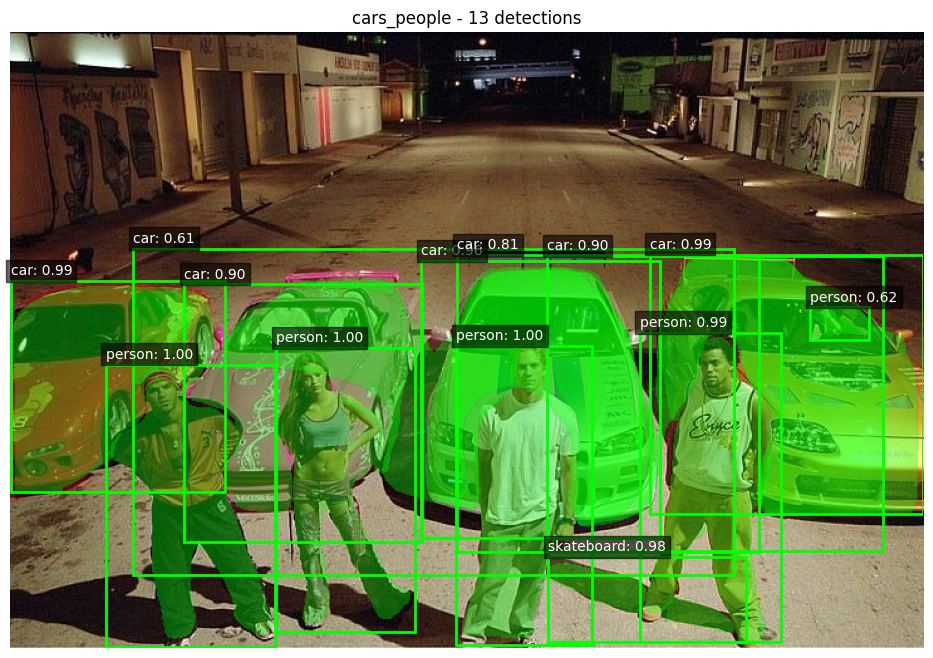

Processing: gang


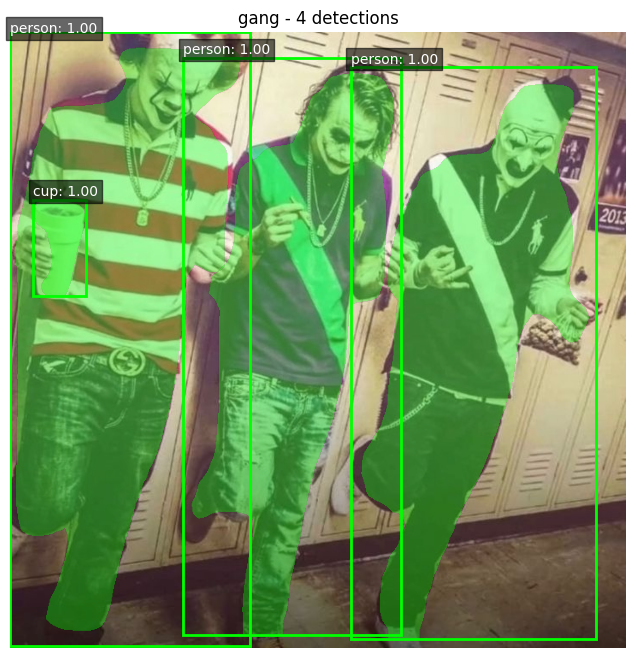

Processing: person


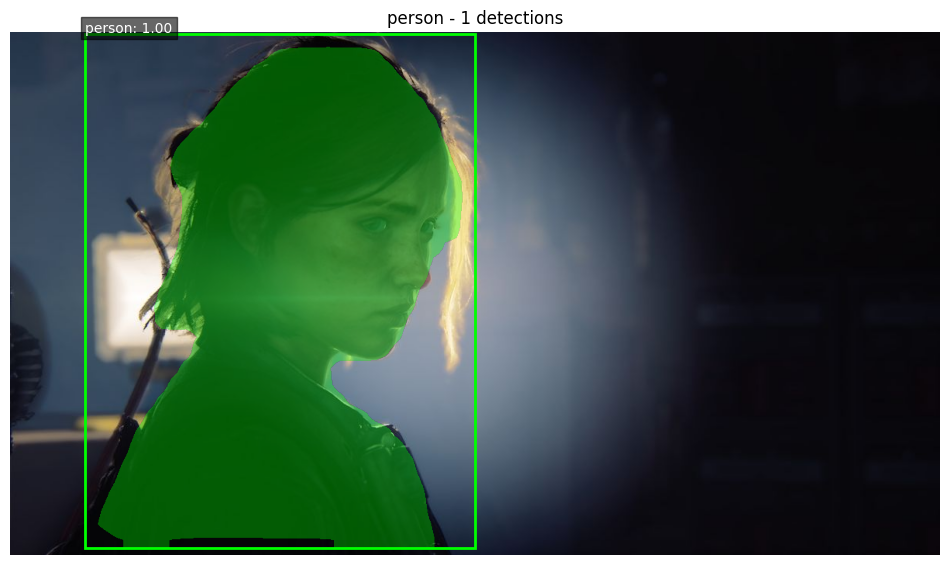

Processing: street


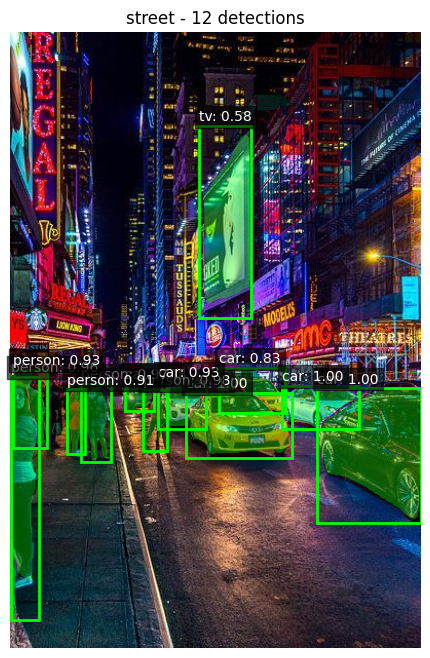

Processing: tamata_cat


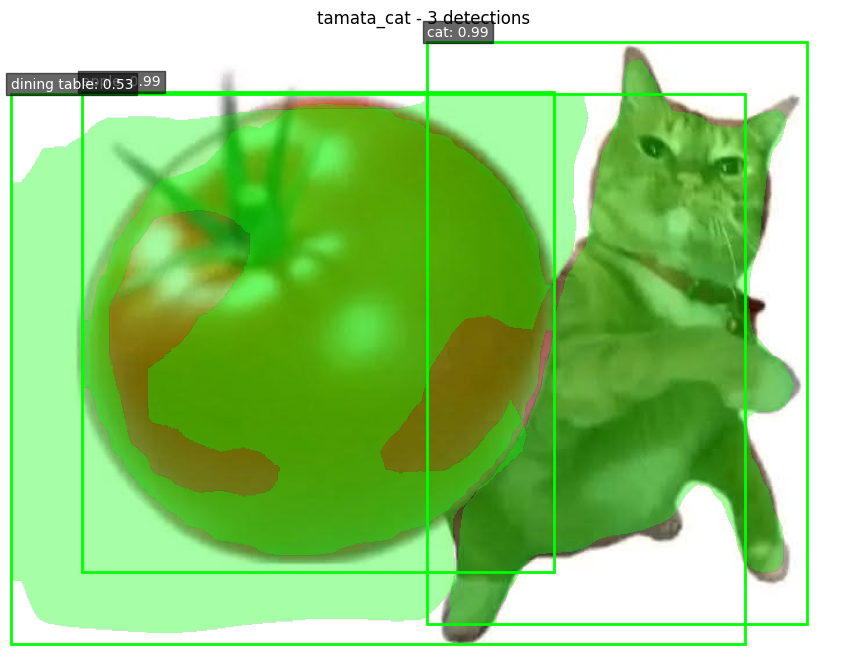


Saved detections table to: outputs\tables\detections.csv
Saved summary table to: outputs\tables\summary.csv
Saved annotated figures to: C:\Users\WinDows\OneDrive\Documents\GitHub\arti560-computer-vision-labs\lab05-object-segmentation\outputs\figures
Saved original images to: C:\Users\WinDows\OneDrive\Documents\GitHub\arti560-computer-vision-labs\lab05-object-segmentation\outputs\images


,image,instance_id,class_id,class_name,score,ymin,xmin,ymax,xmax,has_mask
0,cars_people,1,1,person,0.998954,0.538802,0.103901,0.996660,0.289844,True
1,cars_people,2,1,person,0.996599,0.508806,0.488094,0.994228,0.636252,True
2,cars_people,3,1,person,0.996476,0.512591,0.290189,0.972465,0.442736,True
3,cars_people,4,1,person,0.993919,0.487077,0.688591,0.988973,0.843389,True
4,cars_people,5,3,car,0.992047,0.360197,0.699571,0.781100,0.998699,True
5,cars_people,6,3,car,0.986730,0.403533,0.000000,0.745759,0.234282,True
6,cars_people,7,41,skateboard,0.976896,0.851503,0.588161,0.989379,0.805018,True
7,cars_people,8,3,car,0.962323,0.371359,0.449464,0.819804,0.710566,True
8,cars_people,9,3,car,0.904060,0.408865,0.190242,0.826743,0.450209,True
9,cars_people,10,3,car,0.897458,0.362663,0.587005,0.841031,0.954859,True


In [30]:
detections_df, predictions = run_pipeline(score_threshold=0.5)
detections_df.head(20) if not detections_df.empty else pd.DataFrame()

In [31]:
summary_df = (
    detections_df.groupby(["image", "class_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["image", "count", "class_name"], ascending=[True, False, True])
    if not detections_df.empty
    else pd.DataFrame(columns=["image", "class_name", "count"])
)
summary_df

,image,class_name,count
0,cars_people,car,7
1,cars_people,person,5
2,cars_people,skateboard,1
4,gang,person,3
3,gang,cup,1
5,person,person,1
6,street,car,6
7,street,person,5
8,street,tv,1
9,tamata_cat,apple,1
